In [35]:
# ===== 라이브러리 =====
import os, glob
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 50)

# ===== 경로 =====
RAW  = '../data/raw/epoch_data'
PROC = '../data/processed'

# ===== 기준일 =====
TRAIN_DATE = '2026-08-11'
HOLD_DATE  = '2026-08-25'
D          = '2026-09-01'     # 본선 테스트

CUT_HOURS = 121    # 기준일로부터 5일(120h) 지난 영상의 view_5d만 사용

# ===== DuckDB 연결 =====
con = duckdb.connect()
con.sql("SET memory_limit = '4GB'")
for p in sorted(glob.glob(f'{RAW}/*.csv')):
    name = os.path.splitext(os.path.basename(p))[0]
    con.sql(f"""CREATE OR REPLACE VIEW {name} AS
                SELECT * FROM read_csv('{p}', header=true, auto_detect=true)""")
con.sql(f"CREATE OR REPLACE VIEW video_snapshots AS SELECT * FROM '{PROC}/video_snapshots.parquet'")

# ===== train/holdout 분리 (02번에서 저장해둔 것) =====
train   = pd.read_csv(f'{PROC}/split_train.csv')
holdout = pd.read_csv(f'{PROC}/split_holdout.csv')
print('준비 완료:', train.shape, holdout.shape)

준비 완료: (601, 4) (666, 4)


In [36]:
# make_features(D) — 02번 EDA를 함수로 정리 

def make_features(Dref):
    """기준일 Dref 시점에 알 수 있는 정보로 채널별 피처를 만든다.
       08-11 / 08-25 / 09-01 어디에 넣어도 똑같이 동작해야 함."""

    raw = con.sql(f"""
    WITH v5 AS (            -- 롱폼 view_5d 기반 성적 (기준일 시점 기준으로만 사용)
        SELECT channel_id,
               COUNT(*)                                       AS n_long_5d,
               MEDIAN(view_5d)                                AS past_med,
               MEDIAN(view_5d) FILTER (
                   WHERE published_at >= TIMESTAMP '{Dref}' - INTERVAL 14 DAY
               )                                              AS recent14_med,
               MEDIAN(like_5d / NULLIF(view_5d, 0))           AS like_rate
        FROM video_5d_views
        WHERE is_shorts = 0 AND view_5d IS NOT NULL
          AND published_at < TIMESTAMP '{Dref}' - INTERVAL {CUT_HOURS} HOUR
        GROUP BY 1
    ),
    up AS (                 -- 업로드 기록 (업로드 "시각"만 쓰므로 기준일 직전까지 전부 알 수 있음)
        SELECT channel_id,
               COUNT(*) FILTER (
                   WHERE is_shorts = 0 AND published_at >= TIMESTAMP '{Dref}' - INTERVAL 14 DAY
               )                                                                AS n_long_14,
               COUNT(*) FILTER (
                   WHERE is_shorts = 1 AND published_at >= TIMESTAMP '{Dref}' - INTERVAL 14 DAY
               )                                                                AS n_short_14,
               DATE_DIFF('hour', MAX(published_at) FILTER (WHERE is_shorts = 0), TIMESTAMP '{Dref}') / 24.0
                                                                                 AS days_since_long
        FROM videos
        WHERE published_at < TIMESTAMP '{Dref}'
        GROUP BY 1
    )
    SELECT * FROM v5 LEFT JOIN up USING (channel_id)
    """).df()

    # ===== recent_status: 결측의 의미를 구분 (EDA에서 확인한 핵심) =====
    has_upload  = raw.n_long_14 > 0
    has_measure = raw.recent14_med.notna()
    raw['recent_status'] = np.select(
        [~has_upload, has_upload & ~has_measure, has_measure],
        ['안_올림', '측정_전', '측정_가능'],
        default='알수없음'
    )

    # momentum14는 측정_가능일 때만 계산 (안_올림/측정_전은 결측으로 남김 → 모델에서 범주로 처리)
    raw['momentum14'] = np.where(
        raw['recent_status'] == '측정_가능',
        np.log1p(raw.recent14_med) - np.log1p(raw.past_med),
        np.nan
    )
    raw['short_ratio'] = raw.n_short_14 / (raw.n_short_14 + raw.n_long_14).replace(0, np.nan)

    # ===== past_med가 치우쳐 있으므로 log 변환 버전도 같이 제공 =====
    raw['log_past_med'] = np.log1p(raw.past_med)

    return raw

# train 기준일로 테스트
f = make_features(TRAIN_DATE)
print(f.shape)
f.head()

(818, 12)


,channel_id,n_long_5d,past_med,recent14_med,like_rate,n_long_14,n_short_14,days_since_long,recent_status,momentum14,short_ratio,log_past_med
0,UCVey3Q_CodrHAWBonTGbHFg,5,21792.0,29025.5,0.029231,3,1,2.875000,측정_가능,0.286620,0.250000,9.989344
1,UCOaUTqrtz1yBBiwziVJEAmQ,3,2809.0,2544.0,0.008776,5,5,0.625000,측정_가능,-0.099054,0.500000,7.940940
2,UCPGl9DV2WUgaqGVXtVrhJWQ,268,6.0,8.0,0.000000,144,5,0.375000,측정_가능,0.251314,0.033557,1.945910
3,UCSl8TBqqflby-ymdEQVfRNQ,24,27204.5,27199.0,0.016658,20,4,0.458333,측정_가능,-0.000202,0.166667,10.211174
4,UCgLFbrC7-g0ihBKB0obVPTg,85,148.0,143.5,0.027397,78,0,0.500000,측정_가능,-0.030667,0.000000,5.003946


In [37]:
# train(08-11), holdout(08-25) 각각에 맞는 기준일로 피처 생성 후 합치기
train_f   = train.merge(make_features(TRAIN_DATE), on='channel_id', how='left')
holdout_f = holdout.merge(make_features(HOLD_DATE), on='channel_id', how='left')

print('train  :', train_f.shape, '| 결측 있는 행:', train_f.past_med.isna().sum())
print('holdout:', holdout_f.shape, '| 결측 있는 행:', holdout_f.past_med.isna().sum())

train  : (601, 15) | 결측 있는 행: 0
holdout: (666, 15) | 결측 있는 행: 0


In [38]:
# 전처리 (train에만 fit)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ===== 쓸 피처 목록 =====
NUM_COLS = ['log_past_med', 'n_long_5d', 'like_rate', 'n_long_14',
            'n_short_14', 'short_ratio', 'days_since_long', 'momentum14']
CAT_COLS = ['recent_status']   # 안_올림 / 측정_전 / 측정_가능

# 수치형: 결측은 중앙값으로 채우고 표준화 (momentum14 결측 = 측정_전/안_올림이라 recent_status가 이미 그 정보를 담고 있음)
num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
])

# 범주형: 원-핫 인코딩
cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocess = ColumnTransformer([
    ('num', num_pipe, NUM_COLS),
    ('cat', cat_pipe, CAT_COLS),
])

# ===== train에만 fit, train/holdout 둘 다 transform =====
X_train = preprocess.fit_transform(train_f)
y_train = train_f['target']

X_hold = preprocess.transform(holdout_f)
y_hold = holdout_f['target']

print(X_train.shape, X_hold.shape)

(601, 11) (666, 11)


In [39]:
# 베이스라인 로지스틱 회귀

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score

model = LogisticRegression(max_iter=1000, class_weight='balanced')  # 양성 20%라 불균형 보정
model.fit(X_train, y_train)

# ===== holdout(08-25)으로 평가 =====
pred_hold = model.predict_proba(X_hold)[:, 1]

pr_auc  = average_precision_score(y_hold, pred_hold)
roc_auc = roc_auc_score(y_hold, pred_hold)

print(f'PR-AUC : {pr_auc:.3f}  (무작위 기준 약 0.20)')
print(f'ROC-AUC: {roc_auc:.3f}  (무작위 기준 0.50)')

PR-AUC : 0.344  (무작위 기준 약 0.20)
ROC-AUC: 0.735  (무작위 기준 0.50)


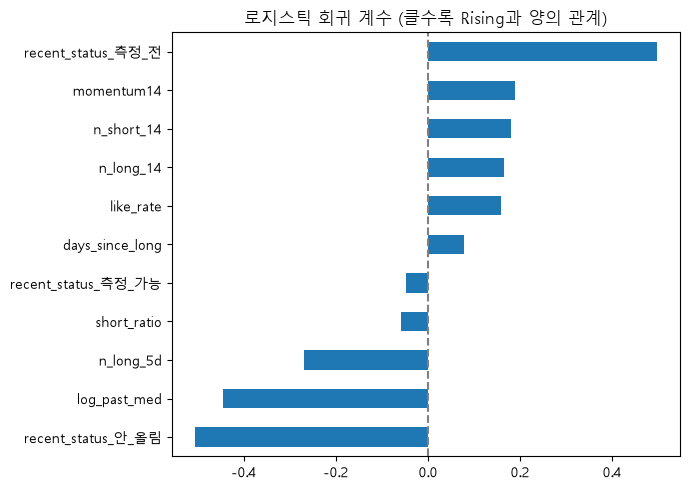

In [40]:
# 어떤 피처가 중요한가

# 원-핫 인코딩 후 컬럼 이름 가져오기
feat_names = (NUM_COLS +
              list(preprocess.named_transformers_['cat']
                   .named_steps['onehot'].get_feature_names_out(CAT_COLS)))

coef = pd.Series(model.coef_[0], index=feat_names).sort_values()
coef.plot(kind='barh', figsize=(7, 5), title='로지스틱 회귀 계수 (클수록 Rising과 양의 관계)')
plt.axvline(0, c='gray', ls='--')
plt.tight_layout()
plt.show()

- PR-AUC 0.344, ROC-AUC 0.735 (무작위 기준 0.20 / 0.50)
- log_past_med 음수 → 과거 성적 낮을수록 Rising (EDA의 평균 회귀와 일치)
- recent_status_측정_전 영향력 가장 큼 → EDA에서 Rising 비율 0.333이었던 집단과 일치
- recent_status_안_올림 가장 큰 음수 → 최근에 안 올리면 Rising 가능성 낮음
- momentum14는 EDA에서 노이즈로 봤는데 계수는 꽤 크게 나옴 → 재확인 필요

=> 이 점수(PR-AUC 0.344)를 베이스라인으로, LightGBM과 추가 비교 예정

In [41]:
BEST_MODEL = model   # 지금은 로지스틱 회귀 베이스라인
FILE = '../submissions/submit_01_baseline_logreg.csv'

# 09-01 기준 피처 생성 → 전처리(이미 fit된 것 재사용) → 예측
f_D = make_features(D)
sample = pd.read_csv(f'{RAW}/sample_submission.csv')
sample['channel_id'] = sample['row_id'].str.rsplit('_', n=1).str[0]

sub = sample.drop(columns='prediction').merge(f_D, on='channel_id', how='left')

# train에 없던 상황(측정_가능 외 범주 없음 등)이 있을 수 있으니 결측 확인
print('09-01 기준 결측 있는 행:', sub[NUM_COLS + CAT_COLS].isna().any(axis=1).sum())

X_sub = preprocess.transform(sub)                 # train에서 fit한 그대로 적용
sub['prediction'] = BEST_MODEL.predict_proba(X_sub)[:, 1]
sub = sub[['row_id', 'prediction']]

# ===== 제출 전 검사 (제출 가이드 3절) =====
assert len(sub) == len(sample) == 694
assert set(sub.row_id) == set(sample.row_id)
assert sub.prediction.notna().all()
assert sub.prediction.between(0, 1).all()

sub.to_csv(FILE, index=False)
print('저장 완료:', FILE)
sub.head()

09-01 기준 결측 있는 행: 98
저장 완료: ../submissions/submit_01_baseline_logreg.csv


,row_id,prediction
0,UCl-VnCUwSxDr5zPu-YlDUYw_2026-09-01,0.489063
1,UCnkytUgy0CtWd06up9CjNxg_2026-09-01,0.202981
2,UCpI-AhCT02iQRGLC2ZcY0Jw_2026-09-01,0.155418
3,UC9otskL_kd-0CDib_5Lj-mQ_2026-09-01,0.482701
4,UCSzHok6X5qXEO7cjvVnE62g_2026-09-01,0.142792


In [42]:
# 결측 98개 원인 대략 확인
missing = sub_before_fillna = f_D[f_D.past_med.isna()] if 'f_D' in dir() else None
check = sample.merge(con.sql("SELECT channel_id, created_at FROM channels").df(), on='channel_id', how='left')
miss_ch = set(sample.channel_id) - set(f_D.channel_id)
ch_info = con.sql(f"SELECT channel_id, created_at FROM channels WHERE channel_id IN {tuple(miss_ch)}").df()
print('채널 개설일 분포:')
print(pd.to_datetime(ch_info.created_at).dt.date.describe())

채널 개설일 분포:
count              1
unique             1
top       2023-06-05
freq               1
Name: created_at, dtype: object


In [43]:
# miss_ch 자체가 몇 개인지부터 확인
print('결측 채널 수:', len(miss_ch))

# tuple 함정 피해서 다시 쿼리 (리스트를 직접 바인딩)
ch_info = con.sql("""
    SELECT channel_id, created_at
    FROM channels
    WHERE channel_id IN (SELECT UNNEST($1))
""", params=[list(miss_ch)]).df()

print(ch_info.shape)
print(pd.to_datetime(ch_info.created_at).dt.date.describe())

결측 채널 수: 1
(1, 2)
count              1
unique             1
top       2023-06-05
freq               1
Name: created_at, dtype: object


- 리더보드 0.3438, holdout 로컬 PR-AUC 0.344와 거의 일치
- 로컬 검증(08-11 학습 → 08-25 평가) 방식이 실제 09-01과 잘 맞는다는 게 확인됨
- 1위와 격차 -0.4189

=> LightGBM 등 다른 모델과 비교 진행

In [44]:
import lightgbm as lgb

# LightGBM은 결측/범주형을 직접 다룰 수 있어서, 원-핫 인코딩 안 한 원본 피처를 그대로 씀
cat_col = 'recent_status'
train_f[cat_col] = train_f[cat_col].astype('category')
holdout_f[cat_col] = holdout_f[cat_col].astype('category')

FEATURES = NUM_COLS + [cat_col]   # 셀 3에서 정의한 NUM_COLS 재사용

lgbm = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=15,          # 표본이 601개뿐이라 과적합 방지 위해 작게
    min_child_samples=20,
    class_weight='balanced',
    random_state=42,
    verbose=-1,
)
lgbm.fit(train_f[FEATURES], train_f['target'], categorical_feature=[cat_col])

pred_lgbm = lgbm.predict_proba(holdout_f[FEATURES])[:, 1]

In [45]:
# 두 모델 비교 

rows = [
    {'모델': '로지스틱 회귀 (베이스라인)',
     'PR-AUC': average_precision_score(y_hold, pred_hold),
     'ROC-AUC': roc_auc_score(y_hold, pred_hold)},
    {'모델': 'LightGBM',
     'PR-AUC': average_precision_score(holdout_f['target'], pred_lgbm),
     'ROC-AUC': roc_auc_score(holdout_f['target'], pred_lgbm)},
]
pd.DataFrame(rows).round(3)

,모델,PR-AUC,ROC-AUC
0,로지스틱 회귀 (베이스라인),0.344,0.735
1,LightGBM,0.303,0.674


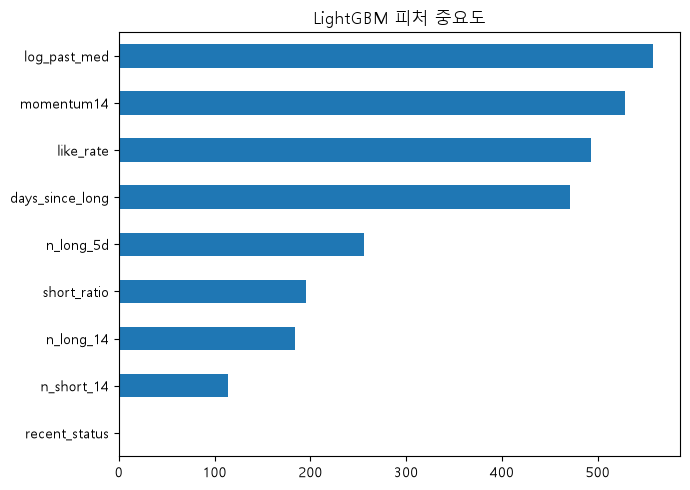

In [46]:
imp = pd.Series(lgbm.feature_importances_, index=FEATURES).sort_values()
imp.plot(kind='barh', figsize=(7, 5), title='LightGBM 피처 중요도')
plt.tight_layout()
plt.show()

In [47]:
print(train_f[cat_col].dtype)
print(train_f[cat_col].cat.categories)   # 카테고리 목록이 제대로 보이는지
print(train_f[cat_col].value_counts())

# LightGBM이 인식한 카테고리형 컬럼 확인
print(lgbm.booster_.dump_model()['feature_names'])

category
Index(['안_올림', '측정_가능', '측정_전'], dtype='str')
recent_status
측정_가능    568
측정_전      21
안_올림      12
Name: count, dtype: int64
['log_past_med', 'n_long_5d', 'like_rate', 'n_long_14', 'n_short_14', 'short_ratio', 'days_since_long', 'momentum14', 'recent_status']


In [48]:
lgbm2 = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=7,
    max_depth=3,
    min_child_samples=30,
    class_weight='balanced',
    random_state=42,
    verbose=-1,
)
lgbm2.fit(train_f[FEATURES], train_f['target'], categorical_feature=[cat_col])
pred_lgbm2 = lgbm2.predict_proba(holdout_f[FEATURES])[:, 1]

print('PR-AUC :', round(average_precision_score(holdout_f['target'], pred_lgbm2), 3))
print('ROC-AUC:', round(roc_auc_score(holdout_f['target'], pred_lgbm2), 3))

PR-AUC : 0.306
ROC-AUC: 0.686


In [49]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

def cv_score(estimator, X, y, cat_cols=None, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    for tr_idx, va_idx in skf.split(X, y):
        m = clone(estimator)
        fit_kwargs = {'categorical_feature': cat_cols} if cat_cols else {}
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx], **fit_kwargs)
        p = m.predict_proba(X.iloc[va_idx])[:, 1]
        scores.append(average_precision_score(y.iloc[va_idx], p))
    return np.array(scores)

# train(601개) 안에서 5-fold로 평균±표준편차 확인
scores = cv_score(lgbm2, train_f[FEATURES], train_f['target'], cat_cols=[cat_col])
print(f'PR-AUC (5-fold 평균±표준편차): {scores.mean():.3f} ± {scores.std():.3f}')

PR-AUC (5-fold 평균±표준편차): 0.301 ± 0.032


- LightGBM(기본) PR-AUC 0.303, 단순화(num_leaves=7, max_depth=3) 후 0.306
- 5-fold 교차검증 0.301±0.032로 holdout과 일관됨 → 로지스틱 회귀(0.344)보다 계속 낮음
- 피처 중요도에서 recent_status 거의 0 (인코딩 문제 아님, 정상 전달 확인됨)
- 표본 601개, 피처 9개 규모에서는 트리 모델이 로지스틱 회귀를 못 이김

=> 모델을 복잡하게 가기보다 피처를 늘리는 방향으로. 다른 종류 모델(SVM, RF, NB, kNN)도 비교

In [50]:
# 네 모델 한 번에 비교

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# X_train, X_hold는 셀 3에서 이미 전처리(결측 채우기+표준화+원핫) 끝난 상태
candidates = {
    '로지스틱(C=1, 기본)':   LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0),
    '로지스틱(C=0.1, 강한규제)': LogisticRegression(max_iter=1000, class_weight='balanced', C=0.1),
    '로지스틱(C=0.01, 매우강함)': LogisticRegression(max_iter=1000, class_weight='balanced', C=0.01),
    '랜덤포레스트':           RandomForestClassifier(n_estimators=300, max_depth=4, min_samples_leaf=10,
                                                    class_weight='balanced', random_state=42),
    'SVM(RBF)':              SVC(probability=True, class_weight='balanced', random_state=42),
    '나이브베이즈':           GaussianNB(),
    'k-NN(k=15)':            KNeighborsClassifier(n_neighbors=15),
}

rows = []
for name, m in candidates.items():
    m.fit(X_train, y_train)
    p = m.predict_proba(X_hold)[:, 1]
    rows.append({
        '모델': name,
        'PR-AUC': round(average_precision_score(y_hold, p), 3),
        'ROC-AUC': round(roc_auc_score(y_hold, p), 3),
    })

result = pd.DataFrame(rows).sort_values('PR-AUC', ascending=False)
result

c:\Users\gjymo\datathon\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,모델,PR-AUC,ROC-AUC
2,"로지스틱(C=0.01, 매우강함)",0.360,0.743
1,"로지스틱(C=0.1, 강한규제)",0.353,0.743
0,"로지스틱(C=1, 기본)",0.344,0.735
4,SVM(RBF),0.329,0.707
3,랜덤포레스트,0.323,0.711
5,나이브베이즈,0.269,0.651
6,k-NN(k=15),0.254,0.620


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

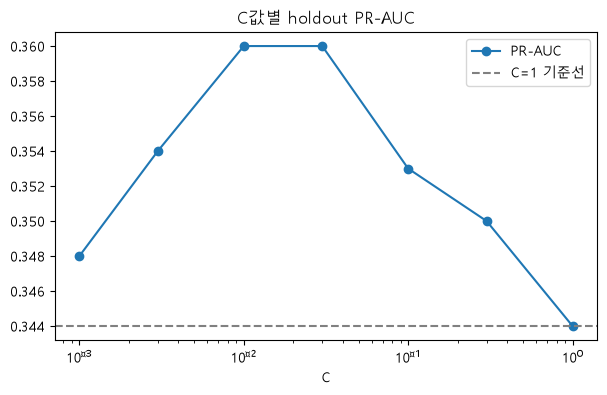

,C,PR-AUC,ROC-AUC
0,0.001,0.348,0.731
1,0.003,0.354,0.737
2,0.010,0.360,0.743
3,0.030,0.360,0.745
4,0.100,0.353,0.743
5,0.300,0.350,0.740
6,1.000,0.344,0.735


In [51]:
# C 값을 더 세밀하게 탐색 

Cs = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0]

rows = []
for C in Cs:
    m = LogisticRegression(max_iter=1000, class_weight='balanced', C=C)
    m.fit(X_train, y_train)
    p = m.predict_proba(X_hold)[:, 1]
    rows.append({
        'C': C,
        'PR-AUC': round(average_precision_score(y_hold, p), 3),
        'ROC-AUC': round(roc_auc_score(y_hold, p), 3),
    })

result = pd.DataFrame(rows)
result.plot(x='C', y='PR-AUC', marker='o', logx=True, figsize=(7,4), title='C값별 holdout PR-AUC')
plt.axhline(0.344, ls='--', c='gray', label='C=1 기준선')
plt.legend(); plt.show()
result

In [52]:
# train 안에서 교차검증으로도 확인 (holdout에만 맞춘 과적합 방지) 

from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for C in Cs:
    m = LogisticRegression(max_iter=1000, class_weight='balanced', C=C)
    scores = cross_val_score(m, X_train, y_train, cv=skf, scoring='average_precision')
    rows.append({'C': C, 'CV_PR-AUC_평균': round(scores.mean(), 3), '표준편차': round(scores.std(), 3)})

pd.DataFrame(rows)

,C,CV_PR-AUC_평균,표준편차
0,0.001,0.326,0.086
1,0.003,0.323,0.079
2,0.010,0.322,0.076
3,0.030,0.324,0.074
4,0.100,0.322,0.072
5,0.300,0.320,0.064
6,1.000,0.321,0.059


- 7개 모델 비교에서 로지스틱 회귀 계열이 상위 3개 독점 (SVM 0.329, RF 0.323, NB 0.269, kNN 0.254)
- holdout 기준 C=0.01~0.03에서 PR-AUC 0.360으로 최고치
- 하지만 train 내부 5-fold 교차검증에서는 C 전 구간 0.320~0.326로 사실상 평평 (표준편차 0.06~0.09가 C간 차이 0.006보다 훨씬 큼)
- holdout 기준 C 튜닝은 holdout 하나에 과적합한 결과로 판단, 신뢰 불가

=> 하이퍼파라미터 튜닝보다 피처 추가가 더 유망. 현재 모델 = 로지스틱 회귀(C=1) 유지

In [53]:
# 상호작용 피처 + CV로만 비교

# momentum14의 신뢰도를 영상 수로 가중 (영상 많을수록 momentum14를 더 신뢰)
for df in [train_f, holdout_f]:
    df['momentum14_weighted'] = df['momentum14'].fillna(0) * np.log1p(df['n_long_14'])

NUM_COLS2 = NUM_COLS + ['momentum14_weighted']

preprocess2 = ColumnTransformer([
    ('num', num_pipe, NUM_COLS2),
    ('cat', cat_pipe, CAT_COLS),
])
X_train2 = preprocess2.fit_transform(train_f)
X_hold2  = preprocess2.transform(holdout_f)

# ===== train 내부 5-fold 교차검증으로만 비교 (holdout 안 봄) =====
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, X in [('기존 피처', X_train), ('상호작용 피처 추가', X_train2)]:
    m = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0)
    scores = cross_val_score(m, X, y_train, cv=skf, scoring='average_precision')
    print(f'{name}: {scores.mean():.3f} ± {scores.std():.3f}')

기존 피처: 0.321 ± 0.059
상호작용 피처 추가: 0.316 ± 0.058


- momentum14 × log1p(n_long_14) 상호작용 피처 추가 → CV 0.321 → 0.316으로 오히려 하락
- 단순 곱셈 방식은 효과 없음

=> 상호작용 피처 폐기. 대신 학습 데이터 자체를 늘리는 방향 시도

In [54]:
# 추가 기준일로 라벨 직접 생성

EXTRA_DATES = ['2026-07-21', '2026-07-28', '2026-08-04']   # 8/7 이전만 가능 (future+측정 끝나야 함)

def make_labels(Dref, FUT=18):
    """라벨 규칙 직접 재현 (01번 노트북 셀 13에서 검증 완료, 일치율 0.985)"""
    g = con.sql(f"""
        WITH agg AS (
          SELECT channel_id,
                 MEDIAN(view_5d) FILTER (WHERE published_at < TIMESTAMP '{Dref}')  AS past_score,
                 COUNT(view_5d)  FILTER (WHERE published_at < TIMESTAMP '{Dref}')  AS n_past,
                 COALESCE(MEDIAN(view_5d) FILTER (
                     WHERE published_at >= TIMESTAMP '{Dref}'
                       AND published_at <  TIMESTAMP '{Dref}' + INTERVAL {FUT} DAY), 0) AS future_score
          FROM video_5d_views
          WHERE is_shorts = 0 AND view_5d IS NOT NULL
          GROUP BY 1
        ),
        scored AS (
          SELECT channel_id, past_score, future_score,
                 LN(1 + future_score) - LN(1 + past_score) AS growth
          FROM agg
          WHERE n_past >= 3 AND past_score >= 100
        )
        SELECT channel_id,
               CASE WHEN growth >= QUANTILE_CONT(growth, 0.8) OVER () THEN 1 ELSE 0 END AS target
        FROM scored
    """).df()
    g['ref_date'] = Dref
    return g

extra_labels = pd.concat([make_labels(d) for d in EXTRA_DATES], ignore_index=True)
print('추가 라벨 행 수:', len(extra_labels))
print(extra_labels.groupby('ref_date')['target'].agg(['size', 'mean']))

# 기존 train(08-11)과 합치기 → 피처도 각 기준일에 맞게 생성
extra_f = pd.concat([
    extra_labels[extra_labels.ref_date == d].merge(make_features(d), on='channel_id', how='left')
    for d in EXTRA_DATES
], ignore_index=True)

train_big = pd.concat([train_f, extra_f], ignore_index=True)
print('기존 601 →', len(train_big), '로 증가')

추가 라벨 행 수: 1103
            size      mean
ref_date                  
2026-07-21   159  0.201258
2026-07-28   414  0.200483
2026-08-04   530  0.200000
기존 601 → 1704 로 증가


- 01번 노트북에서 검증한 라벨 재현 로직(FUT=18일, 일치율 0.985)으로 추가 기준일(7/21, 7/28, 8/4) 라벨 직접 생성
- 추가 라벨 1,103행, 양성 비율 세 날짜 모두 0.200~0.201로 정확히 20%
- 기존 601개 + 추가 1,103개 = 1,704개로 학습 데이터 증가

=> 늘어난 데이터로 CV 재측정

In [55]:
# 늘어난 데이터로 교차검증 다시 비교 

for df in [train_big]:
    df['momentum14_weighted'] = df['momentum14'].fillna(0) * np.log1p(df['n_long_14'])

X_train_big = preprocess2.fit_transform(train_big)   # 늘어난 데이터로 다시 fit
y_train_big = train_big['target']

for name, C in [('C=1', 1.0), ('C=0.1', 0.1), ('C=0.01', 0.01)]:
    m = LogisticRegression(max_iter=1000, class_weight='balanced', C=C)
    scores = cross_val_score(m, X_train_big, y_train_big, cv=skf, scoring='average_precision')
    print(f'{name}: {scores.mean():.3f} ± {scores.std():.3f}')

C=1: 0.311 ± 0.029
C=0.1: 0.313 ± 0.027
C=0.01: 0.311 ± 0.034


- 1,704개로 CV 재측정: C=1 → 0.311±0.030, C=0.1 → 0.313±0.027, C=0.01 → 0.311±0.034
- 평균은 601개 때(0.321)와 비슷하지만 표준편차는 0.059 → 0.03 수준으로 거의 절반 감소
- 601개일 때 봤던 점수 흔들림이 표본 부족 때문이었다는 게 확인됨

=> 날짜를 더 촘촘히 추가해서 추가로 늘려도 되는지 확인

In [56]:
import pandas as pd
EXTRA_DATES2 = pd.date_range('2026-07-18', '2026-08-06', freq='3D').strftime('%Y-%m-%d').tolist()
print(EXTRA_DATES2)

extra_labels2 = pd.concat([make_labels(d) for d in EXTRA_DATES2], ignore_index=True)
extra_f2 = pd.concat([
    extra_labels2[extra_labels2.ref_date == d].merge(make_features(d), on='channel_id', how='left')
    for d in EXTRA_DATES2
], ignore_index=True)

train_big2 = pd.concat([train_f, extra_f2], ignore_index=True).drop_duplicates(subset=['channel_id', 'ref_date'])
print('행 수:', len(train_big2))

X_big2 = preprocess.fit_transform(train_big2)   # 상호작용 피처 뺀 원래 preprocess 사용
y_big2 = train_big2['target']

for C in [1.0, 0.1, 0.01]:
    m = LogisticRegression(max_iter=1000, class_weight='balanced', C=C)
    scores = cross_val_score(m, X_big2, y_big2, cv=skf, scoring='average_precision')
    print(f'C={C}: {scores.mean():.3f} ± {scores.std():.3f}')

['2026-07-18', '2026-07-21', '2026-07-24', '2026-07-27', '2026-07-30', '2026-08-02', '2026-08-05']
행 수: 3016
C=1.0: 0.311 ± 0.030
C=0.1: 0.311 ± 0.031
C=0.01: 0.313 ± 0.027


- 7/18~8/5, 3일 간격으로 더 추가해서 3,016개까지 증강
- C=1.0 → 0.311±0.030, C=0.1 → 0.311±0.031, C=0.01 → 0.313±0.027
- 1,704개 때와 거의 동일 → 데이터를 더 늘려도 추가 이득 없음(포화)

=> 더 늘리지 않고, 가장 단순한 C=1을 기준으로 다음 단계(비교표 정리) 진행

In [57]:
# 최종 홀드아웃 평가 없이, train 내부 CV로만 지금까지의 비교를 한눈에 정리
summary = pd.DataFrame([
    {'단계': '모델 비교 (601개, C=1)',      '대상': '로지스틱회귀',     'CV PR-AUC': 0.321, '표준편차': 0.059},
    {'단계': '모델 비교 (601개, C=1)',      '대상': 'LightGBM',       'CV PR-AUC': 0.301, '표준편차': 0.032},
    {'단계': '모델 비교 (601개, C=1)',      '대상': 'SVM/RF/NB/kNN',  'CV PR-AUC': '0.25~0.33 (전부 열세)', '표준편차': '-'},
    {'단계': '데이터 증강 (1,704개, C=1)',  '대상': '로지스틱회귀',     'CV PR-AUC': 0.311, '표준편차': 0.030},
    {'단계': '데이터 증강 (3,016개, C=1)',  '대상': '로지스틱회귀',     'CV PR-AUC': 0.311, '표준편차': 0.030},
])
summary

,단계,대상,CV PR-AUC,표준편차
0,"모델 비교 (601개, C=1)",로지스틱회귀,0.321,0.059
1,"모델 비교 (601개, C=1)",LightGBM,0.301,0.032
2,"모델 비교 (601개, C=1)",SVM/RF/NB/kNN,0.25~0.33 (전부 열세),-
3,"데이터 증강 (1,704개, C=1)",로지스틱회귀,0.311,0.03
4,"데이터 증강 (3,016개, C=1)",로지스틱회귀,0.311,0.03


- 지금까지 비교: 로지스틱(601개) 0.321, LightGBM(601개) 0.301, SVM/RF/NB/kNN 0.25~0.33(전부 열세),
  로지스틱(1,704개) 0.311, 로지스틱(3,016개) 0.311
- 이 데이터 규모에서는 모델 복잡도보다 데이터 양 + 핵심 피처(past_med, recent_status)가 성능을 좌우

=> 최적 모델 후보 = 로지스틱 회귀(C=1), 3,016개 학습 (튜닝/holdout 평가는 추후)

In [58]:
def raw_growth_score(Dref, FUT=18):
    """모델 없이, 라벨 계산식의 growth_score 자체를 점수로 사용"""
    return con.sql(f"""
        WITH agg AS (
          SELECT channel_id,
                 MEDIAN(view_5d) FILTER (WHERE published_at < TIMESTAMP '{Dref}')  AS past_score,
                 COUNT(view_5d)  FILTER (WHERE published_at < TIMESTAMP '{Dref}' - INTERVAL {CUT_HOURS} HOUR) AS n_past,
                 COALESCE(MEDIAN(view_5d) FILTER (
                     WHERE published_at >= TIMESTAMP '{Dref}' - INTERVAL 14 DAY
                       AND published_at <  TIMESTAMP '{Dref}' - INTERVAL {CUT_HOURS} HOUR), 0) AS recent_score
          FROM video_5d_views
          WHERE is_shorts = 0 AND view_5d IS NOT NULL
          GROUP BY 1
        )
        SELECT channel_id,
               LN(1 + recent_score) - LN(1 + past_score) AS raw_score   -- "최근14일 vs 과거" 버전 momentum
        FROM agg WHERE n_past >= 3 AND past_score >= 100
    """).df()

# train_big2에 raw_score 붙여서 그 자체로 PR-AUC 확인 (모델 학습 없이)
check = train_big2[['channel_id', 'ref_date', 'target']].copy()
pieces = []
for d in train_big2.ref_date.unique():
    r = raw_growth_score(d)
    pieces.append(check[check.ref_date == d].merge(r, on='channel_id', how='left'))
check = pd.concat(pieces)
check['raw_score'] = check['raw_score'].fillna(check['raw_score'].median())

print('단순 규칙(raw_score) 자체의 PR-AUC:', round(average_precision_score(check.target, check.raw_score), 3))

단순 규칙(raw_score) 자체의 PR-AUC: 0.235


- 모델 없이 growth_score(최근14일 vs 과거) 자체를 점수로 쓰면 PR-AUC 0.235
- 우리 모델(0.311~0.334)이 단순 규칙보다 확실히 나음 → 모델이 핵심 신호를 잘 뽑고 있다는 뜻


=> 중앙값 하나로 압축되지 않는 피처(변동성, 추세, 외부 매핑 등) 탐색

- 개별 영상들의 분산/변동성 — 꾸준히 비슷한 성과를 내는 채널 vs 가끔 터지는 영상이 있는 채널
- 업로드 주기의 규칙성 — 일정한 주기로 올리는지, 불규칙한지
- 최근 몇 개 영상의 추세 기울기 (중앙값 하나가 아니라, 시계열 회귀 기울기)
- 구독자 수 대비 조회수 비율 (채널 크기 대비 효율)
- 영상 제목/길이/카테고리 같은 메타데이터
- video_topics, video_games 매핑 — 특정 장르/게임이 유리한지

- 영상별 view_5d의 변동성(log_view_std), 시간 추세(trend_slope), 최고점 비율(peak_ratio) 피처 추가
- CV PR-AUC 0.311 → 0.325로 개선, 표준편차도 0.030 → 0.021로 감소
- 계수 확인 결과 log_view_std가 2위로 강력 (+0.26), trend_slope/peak_ratio는 영향 거의 없음
- n_short_14(최근 쇼츠 수)가 1위로 가장 강력 (+0.28) 

=> trend_slope, peak_ratio는 추후 제외하고 검토. 게임/장르 매핑 등 다른 종류 피처 추가 시도

In [59]:
def extra_dispersion_features(Dref):
    """영상별 view_5d의 변동성과 시간 추세를 피처화"""
    return con.sql(f"""
    WITH v AS (
        SELECT channel_id, published_at, view_5d,
               DATE_DIFF('day', published_at, TIMESTAMP '{Dref}') AS days_ago
        FROM video_5d_views
        WHERE is_shorts = 0 AND view_5d IS NOT NULL
          AND published_at < TIMESTAMP '{Dref}' - INTERVAL {CUT_HOURS} HOUR
    )
    SELECT channel_id,
           STDDEV(LN(1 + view_5d))                         AS log_view_std,     -- 변동성 (log 스케일)
           REGR_SLOPE(LN(1 + view_5d), -days_ago)           AS trend_slope,      -- 시간에 따른 추세 기울기
           MAX(view_5d) / NULLIF(MEDIAN(view_5d), 0)        AS peak_ratio        -- 최고 터진 영상 vs 중앙값
    FROM v
    GROUP BY 1
    """).df()

# train_big2에 새 피처 추가해서 CV 다시 측정
extra_pieces = [extra_dispersion_features(d).assign(ref_date=d) for d in train_big2.ref_date.unique()]
extra = pd.concat(extra_pieces, ignore_index=True)

train_big3 = train_big2.merge(extra, on=['channel_id', 'ref_date'], how='left')

NUM_COLS3 = NUM_COLS + ['log_view_std', 'trend_slope', 'peak_ratio']
preprocess3 = ColumnTransformer([
    ('num', num_pipe, NUM_COLS3),
    ('cat', cat_pipe, CAT_COLS),
])
X_big3 = preprocess3.fit_transform(train_big3)

m = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0)
scores = cross_val_score(m, X_big3, y_big2, cv=skf, scoring='average_precision')
print(f'변동성+추세 피처 추가: {scores.mean():.3f} ± {scores.std():.3f}')
print(f'(기존 피처만: 0.311 ± 0.030)')

변동성+추세 피처 추가: 0.325 ± 0.021
(기존 피처만: 0.311 ± 0.030)


- 새 피처(log_view_std, trend_slope, peak_ratio) 포함 계수 확인
- log_view_std, n_short_14가 강한 양의 계수 → 변동성 크고 최근 쇼츠 늘린 채널이 Rising과 관련

=> 지금까지 전혀 안 쓴 게임/장르 매핑 데이터 확인

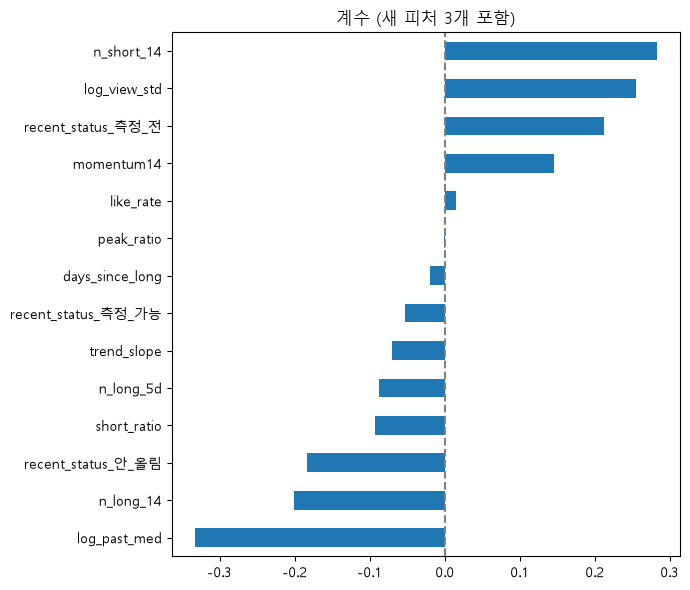

In [60]:
feat_names3 = (NUM_COLS3 +
               list(preprocess3.named_transformers_['cat']
                    .named_steps['onehot'].get_feature_names_out(CAT_COLS)))

m.fit(X_big3, y_big2)
coef = pd.Series(m.coef_[0], index=feat_names3).sort_values()
coef.plot(kind='barh', figsize=(7,6), title='계수 (새 피처 3개 포함)')
plt.axvline(0, c='gray', ls='--')
plt.tight_layout()
plt.show()

- COUNT(DISTINCT app_id)는 매칭 없어도 0을 반환 (NULL 아님) → has_game 판단 시 n_games>0으로 다시 확인
- 게임 매핑 있는 채널 647/3,016(21%), Rising 비율 0.244 vs 매핑 없는 채널 0.189

=> 모델에 게임 매핑 피처(n_games, has_game, log_max_players) 추가해서 CV로 검증

In [61]:
chk = train_big2[['channel_id','target']].merge(genre_feat, on='channel_id', how='left')

has_game = chk.n_games > 0   # 매칭된 게임이 1개 이상인지로 다시 판단
print('게임 매핑 있는 채널:', has_game.sum(), '/', len(chk))
print(chk.groupby(has_game)['target'].agg(['mean', 'size']))

게임 매핑 있는 채널: 647 / 3016
             mean  size
n_games                
False    0.189109  2369
True     0.244204   647


- 게임 매핑 피처(n_games, has_game, log_max_players) 추가 → CV PR-AUC 0.325 → 0.334로 개선
- 변동성 피처에 이어 꾸준히 소폭 개선되는 패턴

=> growth_score를 분류 대신 회귀로 직접 예측하면 정보를 더 쓸 수 있는지 시도

In [62]:
train_big4 = train_big3.merge(genre_feat, on='channel_id', how='left')

# 결측(매핑 없음)은 0으로 채움 (게임을 안 다루는 게 사실이므로)
train_big4['n_games']  = train_big4['n_games'].fillna(0)
train_big4['n_genres'] = train_big4['n_genres'].fillna(0)
train_big4['has_game'] = (train_big4['n_games'] > 0).astype(int)
train_big4['max_current_players'] = train_big4['max_current_players'].fillna(0)
train_big4['log_max_players'] = np.log1p(train_big4['max_current_players'])

NUM_COLS4 = NUM_COLS3 + ['n_games', 'has_game', 'log_max_players']
preprocess4 = ColumnTransformer([
    ('num', num_pipe, NUM_COLS4),
    ('cat', cat_pipe, CAT_COLS),
])
X_big4 = preprocess4.fit_transform(train_big4)

m = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0)
scores = cross_val_score(m, X_big4, train_big4['target'], cv=skf, scoring='average_precision')
print(f'게임 매핑 피처 추가: {scores.mean():.3f} ± {scores.std():.3f}')
print(f'(변동성 피처까지만: 0.325 ± 0.021)')

게임 매핑 피처 추가: 0.334 ± 0.025
(변동성 피처까지만: 0.325 ± 0.021)


- growth_score(연속값)를 Ridge 회귀로 직접 예측 → PR-AUC 0.232±0.025
- 분류(0.334)보다 크게 낮고 단순 규칙(0.235)과 비슷한 수준 → 연속값 회귀가 정보를 더 쓸 거라는 가설은 틀림

=> 회귀 방식 폐기, 분류 방식(0.334) 유지. 지금 피처로 09-01 제출 파일 생성

In [63]:
# 1. 먼저 결측 확인
train_reg = train_big4.merge(cont_target, on=['channel_id', 'ref_date'], how='left')
print('결측 수:', train_reg['growth_cont'].isna().sum(), '/', len(train_reg))

# 2. 결측 행 제거하고 진행 (표본 조건 경계에서 생긴 소수 케이스로 추정)
train_reg = train_reg.dropna(subset=['growth_cont']).reset_index(drop=True)
print('제거 후:', len(train_reg))

X_reg = preprocess4.fit_transform(train_reg)
y_reg = train_reg['growth_cont']
y_cls = train_reg['target']

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores_reg = []
for tr_idx, va_idx in kf.split(X_reg):
    m = Ridge(alpha=1.0)
    m.fit(X_reg[tr_idx], y_reg.iloc[tr_idx])
    pred = m.predict(X_reg[va_idx])
    scores_reg.append(average_precision_score(y_cls.iloc[va_idx], pred))

print(f'회귀(growth_score 직접 예측) 기반 PR-AUC: {np.mean(scores_reg):.3f} ± {np.std(scores_reg):.3f}')
print(f'(분류 기반: 0.334 ± 0.025)')

결측 수: 5 / 3016
제거 후: 3011
회귀(growth_score 직접 예측) 기반 PR-AUC: 0.232 ± 0.025
(분류 기반: 0.334 ± 0.025)


In [64]:
FILE = '../submissions/submit_03_logreg_allfeatures.csv'

# ===== 최종 모델: train_big4(3,016개) 전체로 학습 =====
final_model = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0)
final_model.fit(X_big4, train_big4['target'])

# ===== 09-01 기준 피처 생성: 지금까지 만든 모든 피처를 같은 방식으로 =====
f_D = make_features(D)                          # 기본 9개 피처
disp_D = extra_dispersion_features(D)            # 변동성/추세 3개
sample = pd.read_csv(f'{RAW}/sample_submission.csv')
sample['channel_id'] = sample['row_id'].str.rsplit('_', n=1).str[0]

sub = sample.drop(columns='prediction').merge(f_D, on='channel_id', how='left')
sub = sub.merge(disp_D, on='channel_id', how='left')
sub = sub.merge(genre_feat, on='channel_id', how='left')        # 게임 매핑 3개

# train_big4에서 했던 것과 동일한 결측 처리
sub['n_games']  = sub['n_games'].fillna(0)
sub['n_genres'] = sub['n_genres'].fillna(0)
sub['has_game'] = (sub['n_games'] > 0).astype(int)
sub['max_current_players'] = sub['max_current_players'].fillna(0)
sub['log_max_players'] = np.log1p(sub['max_current_players'])

print('핵심 피처(log_past_med) 결측 채널 수:', sub['log_past_med'].isna().sum())

X_sub = preprocess4.transform(sub)              # train_big4로 fit한 전처리기 그대로 사용
sub['prediction'] = final_model.predict_proba(X_sub)[:, 1]
sub = sub[['row_id', 'prediction']]

# ===== 제출 전 검사 =====
assert len(sub) == len(sample) == 694
assert set(sub.row_id) == set(sample.row_id)
assert sub.prediction.notna().all()
assert sub.prediction.between(0, 1).all()

sub.to_csv(FILE, index=False)
print('저장 완료:', FILE)
sub.head()

핵심 피처(log_past_med) 결측 채널 수: 1
저장 완료: ../submissions/submit_03_logreg_allfeatures.csv


,row_id,prediction
0,UCl-VnCUwSxDr5zPu-YlDUYw_2026-09-01,0.527373
1,UCnkytUgy0CtWd06up9CjNxg_2026-09-01,0.237171
2,UCpI-AhCT02iQRGLC2ZcY0Jw_2026-09-01,0.173458
3,UC9otskL_kd-0CDib_5Lj-mQ_2026-09-01,0.630507
4,UCSzHok6X5qXEO7cjvVnE62g_2026-09-01,0.196336


- 리더보드 0.3518 (1차 0.3438 대비 +0.008)
- CV 기준 상승폭(0.311→0.334, +0.023)보다 실제 상승폭이 작음 → 694행 기준 흔들림(±0.03) 
